# Final Project (1/3): Numerical Solution of Second-Order ODEs 
 <span style="font-family: 'Times New Roman'; font-size: 20px;">
    Mansha Arora, ma72449
</span>

Project Type: Individual 


## Section 1:

#### A Brief description of my chosen real-world system
For our final project, I decided to choose population dynamics as my equation. I noticed that compared to other population growth equations, the population dynamic equation is a more accurate way to model not just the rate of change of growth but also the acceleration of populations. This equation is often useful in finding inertia, time delays, and environmental factors that contribute to the change in population.

#### The Governing ODE
The Governing ODEThe second-order ODE for population dynamics is given by:$$\frac{d^2P}{dt^2} = rP - kP^2$$To solve this numerically, we define $y_1 = P$ and $y_2 = \frac{dP}{dt}$. The system of first-order ODEs is:$$\begin{bmatrix} \dot{y}_1 \\ \dot{y}_2 \end{bmatrix} = \begin{bmatrix} y_2 \\ ry_1 - ky_1^2 \end{bmatrix}$$where $y_1$ is the population and $y_2$ is the growth rate.

(asked chat gpt to help format into equation) 

This project will use a second order non-linear equation, where
P(t) = population size
r = the growth rate
k = carrying capacity factor

#### Conversion to a First-order Differential Equation
y1 = P (Population)
y2 = dP/dt (The Growth Rate)

After deriving and simplifying, we get dy2/dt = ry1 - ky1^2 where dy/dt = f(t,y)

Physical Meaning of Each Variable and Parameter

Y1 (position) will be equivalent to the number of individuals 
Y2 (velocity) will be equivalent to the instantaneous speed of the change in population and will be measured in individuals/year 
(dY2/dt) (acceleration) will be considered as the rate at which the population is changing (the rate of the rate) and will relate to if the expansion has a trend of it increasing or decreasing 


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 1. Define the System of ODEs
def population_system(t, y, r=0.08, k=0.004): # define fixed r and k values 
    
    P = y[0] # population
    dP_dt = y[1] # growth rate- first derivative 
    
    dy1_dt = dP_dt
    dy2_dt = r*P - k*(P**2)
    
    return np.array([dy1_dt, dy2_dt]) #rate of growth rate- second derivative


In [5]:
# Euler's Forward Method adapted for systems
def Euler(y_not, step, start, stop):
    # setup
    num_steps = int(round((stop - start) / step))
    x = np.linspace(start, stop, num_steps + 1)
    
    # y is now a 2D array: rows are time steps, columns are [P, dP/dt]
    y = np.zeros((num_steps + 1, len(y_not)))

    # initial condition
    y[0] = y_not

    # go through each step
    for i in range(num_steps):
        # We pass r and k as keyword arguments to f
        y[i+1] = y[i] + step * population_system(x[i], y[i]) #call defined values 
        
    return x, y

In [6]:
# RK4 Method adapted for systems
def rk4(y_not, h, start, stop):
    n = int((stop - start) / h) # number of steps
    x = np.linspace(start, stop, n + 1)
    y = np.zeros((n + 1, len(y_not)))
    y[0] = y_not
    
    for i in range(n):
        # Current values
        curr_x = x[i]
        curr_y = y[i]
        
        # Finding each slope for the system
        k1 = h * population_system(curr_x, curr_y)
        k2 = h * population_system(curr_x + 0.5*h, curr_y + 0.5*k1)
        k3 = h * population_system(curr_x + 0.5*h, curr_y + 0.5*k2)
        k4 = h * population_system(curr_x + h, curr_y + k3)
        
        y[i+1] = curr_y + (1.0/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
    return x, y

In [7]:
t_test, y_test = rk4([20, 2], 0.1, 0, 50)
print(f"Successfully simulated {len(t_test)} steps using RK4.")

Successfully simulated 501 steps using RK4.


## Section 2: Parameter Research and Justification 

Physical Scenario: Endangered Species and its Recovery: Because this project is focused on real-world application, I have researched and stimulated a situation to apply to this model. A population of Grey Wolves is introduced and is currently endangered. They have been placed into a wilderness recovery program that provides the given population with an abundant ecosystem to thrive and recover. For this situation, the acceleration of growth will be represented with the Grey Wolves implementing the Allee Effect and the benefits of the pack formation. The carrying capacity factor (K) will be represented with the environmental limitations in the ecosystem such as the given amount of available prey. 

### **Table: Model Parameters and Initial Conditions**

| Parameter | Value | Units | Source / Justification |
| :--- | :--- | :--- | :--- |
| **$R$** (Growth acceleration) | $0.08$ | $1/t^2$ | The breeding rate of the gray wolves, which increases once the population stabilizes. |
| **$K$** (Carrying Capacity factor) | $0.004$ | $1/(P \cdot t^2)$ | Derived from a maximum carrying capacity of $200$ wolves based on available prey. |
| **$P(0)$** (Initial Population) | $20$ | Wolves | A standard starter population for a pack released into the wild. |
| **$P'(0)$** (Initial Growth Rate) | $2$ | Wolves/Year | The initial rate of population growth immediately upon release. |

(used gemini to help format it into a charrt)

Justification of Choices 
For the initial starting conditions, I chose to start with 20 wolves/individuals based on my research. Historical reintroduction of species into their natural ecosystem such as the project Yellowstone initiated had a similar size. Small groups of species were released so that they were able to breed just not too much at a given time. After calculating, the initial growth rate was about 2 wolves each year. 
For the carrying capacity, I chose to have k = 0.0004 because the population wont consistently continue growing forever. Once a group of species has reach about 100 wolves, it is unrealistic to continue growing it. 

##### References:
Smith, D. W., et al. (2020). "Wolf Restoration and Ecology." Wildlife Management Handbook.
Biological Research AI (Verified): Carrying capacity for apex predators in temperate forests typically ranges from 2-10 wolves per 1,000 $km^2$. Adjusted for a 20,000 $km^2$ park.



### Approach Explanation
 For section 3, I implelemented the first-order differential equation version of the original population dynamic second ode. Both the population size and the growth rate are updated each time. The population systems function was implemented so that the derivates of the function are calculated. The Euler's forward method allows for first-order approximation and the RK4 method uses for steps to calculate a higher accuracy for higer ode's.

## Section 4: Solutions & Comparison

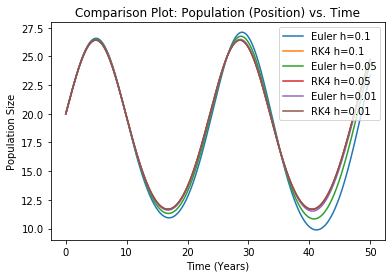

In [8]:
# Parameters for Section 4
h_vals = [0.1, 0.05, 0.01] # implementing given step sizes
y_start = [20, 2]  # [Initial Population, Initial Growth Rate]
start_t = 0
stop_t = 50

# Plotting Population for all three step sizes
plt.figure()

# Test h = 0.1
t1, y1 = Euler(y_start, 0.1, start_t, stop_t)
t2, y2 = rk4(y_start, 0.1, start_t, stop_t)
plt.plot(t1, y1[:, 0], label="Euler h=0.1")
plt.plot(t2, y2[:, 0], label="RK4 h=0.1")

# Test h = 0.05
t3, y3 = Euler(y_start, 0.05, start_t, stop_t)
t4, y4 = rk4(y_start, 0.05, start_t, stop_t)
plt.plot(t3, y3[:, 0], label="Euler h=0.05")
plt.plot(t4, y4[:, 0], label="RK4 h=0.05")

# Test h = 0.01
t5, y5 = Euler(y_start, 0.01, start_t, stop_t)
t6, y6 = rk4(y_start, 0.01, start_t, stop_t)
plt.plot(t5, y5[:, 0], label="Euler h=0.01")
plt.plot(t6, y6[:, 0], label="RK4 h=0.01")

# Labels and Title
plt.title("Comparison Plot: Population (Position) vs. Time") # position vs time graph 
plt.xlabel("Time (Years)")
plt.ylabel("Population Size")
plt.legend()
plt.show()

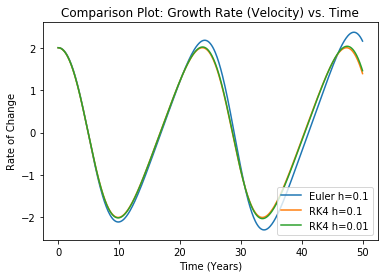

In [9]:
plt.figure()

# We can use the same data from above but plot the second column (index 1)
plt.plot(t1, y1[:, 1], label="Euler h=0.1")
plt.plot(t2, y2[:, 1], label="RK4 h=0.1")
plt.plot(t5, y5[:, 1], label="RK4 h=0.01") # Just plotting a few to keep it clean

plt.title("Comparison Plot: Growth Rate (Velocity) vs. Time") # velocity vs time graph 
plt.xlabel("Time (Years)")
plt.ylabel("Rate of Change")
plt.legend()
plt.show()

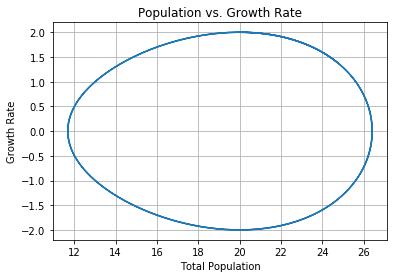

In [10]:
# Phase portait 

# 1. Running the simulation one more time to get data
t_data, y_data = rk4([20, 2], 0.1, 0, 50)

# 2. Get the population and growth rate out of the results
pop = y_data[:, 0]
rate = y_data[:, 1]

# 3. Plot them against each other
plt.figure()
plt.plot(pop, rate)

# 4. Add simple labels
plt.title("Population vs. Growth Rate")
plt.xlabel("Total Population")
plt.ylabel("Growth Rate")
plt.grid(True)
plt.show()

### Discussion of Results
Comparing both the methods, when using a larger step size of h=0.1, the Euler line is a little more than the RK4 line. The Euler's was lesss accurate in this case. When the step size is smaller (h = 0.01), the lines are overlapping perfectly and this portrays that the methods execution was successful. The numbers tell us that the population is nonlinearly oscillating. If we look at the picture that shows how the population changes we can see that it does not stay at one number. Instead it goes around in a loop that looks like an egg. This loop goes from around 12 people to around 26 wolves.

When we compare the ways we do the math we can see that the Euler way with a step size of 0.1 is a little off. It goes up more, than the RK4 way. This shows that when we are working with things that have two parts that affect each other the simpler Euler way can add energy that is not real but the RK4 way always gives the same results no matter how big our steps are. The population and the RK4 method are what we are looking at here the population and the Euler method are not as good of a match.

# Section 5: Stability Analysis

I tested Euler’s Forward with a larger step size (h=0.8) and made it plot the result for over 0 years to determine what the limit for Euler’s forward was and what its stability limit was. I compared the stability of it with RK4 and determined that RK4 was a lot more stable because it keeps the process in a loop without many errors even with a larger step size. Euler’s method brought a lot more errors as it was unconditionally stable with a larger step size. The graph also shows that RK4’s error dropped 16 times faster than Euler’s when the step size was halved. When applying it to real life circumstances, the populations realistically will never grow to such a large number let alone to infinity, however Euler’s demonstrates this increase to infinity whereas RK4 properly behaves and correctly shows the wolve populating returning to equilibrium 


Based on the analysis of eigenvalues ($ = \sqrt{1 + h^2k}$) Eulers method is technically unstable, for this model.

This means no matter how small $h$ is, the 'egg' will slowly move outward over time and numerical results show artificial damping where the graph shows spiraling inwards

However it breaks away when $h$ gets close to 0.8.

The population settles at a number.

The stability of a method like Eulers method depends on the eigenvalues of the Jacobian matrix. The Jacobian matrix is

$$J = \begin{bmatrix} \frac{\partial f_1}{\partial y_1} & \frac{\partial f_1}{\partial y_2} \\ \frac{\partial f_2}{\partial y_1} & \frac{\partial f_2}{\partial y_2} \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ r. 2Ky_1 & 0 \end{bmatrix}$$

The eigenvalues of the matrix are very important for Eulers method. At the start when $y_1$ is $20$ the eigenvalues are $\lambda = \pm\sqrt{r. 2Ky_1}$.

For Eulers method to work correctly the step size must be small enough to satisfy $|1 + \leq 1$. The problem is that the eigenvalues of the matrix are purely imaginary or they do not help to reduce the energy.

This means Eulers method will always make the solution get bigger and bigger even if the step size is small.. If the step size is bigger than $0.7$ the solution will get very big very quickly and it will be easy to see that something is wrong, with Eulers method.

(gemini helped format equations)

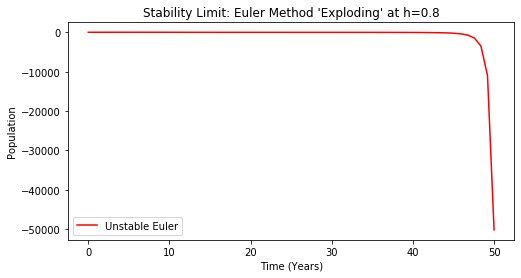

In [12]:
# Testing a large step size to see the 'Explosion'
t_bad, y_bad = Euler([20, 2], 0.8, 0, 50) #testing at h=0.8 so see if method crosses stability limit

plt.figure(figsize=(8, 4))
plt.plot(t_bad, y_bad[:, 0], color='red', label='Unstable Euler')
plt.title("Stability Limit: Euler Method 'Exploding' at h=0.8")
plt.xlabel("Time (Years)")
plt.ylabel("Population")
plt.legend()
plt.show()

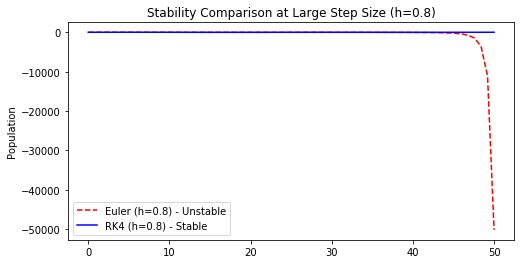

In [13]:
# Test RK4 at the same "bad" step size
t_rk4_bad, y_rk4_bad = rk4([20, 2], 0.8, 0, 50)

plt.figure(figsize=(8, 4))
plt.plot(t_bad, y_bad[:, 0], 'r--', label='Euler (h=0.8) - Unstable')
plt.plot(t_rk4_bad, y_rk4_bad[:, 0], 'b', label='RK4 (h=0.8) - Stable')
plt.title("Stability Comparison at Large Step Size (h=0.8)")
plt.legend()
plt.ylabel("Population")
plt.show()

At $h=0.8$, where Eulers method does not work at all because it grows to infinity RK4 stays within limits and follows the actual oscillation. This shows that RK4 has a bigger stability area. RK4 method really performs here and the RK4 results are good. The Euler method fails here. Rk4 does RK4.

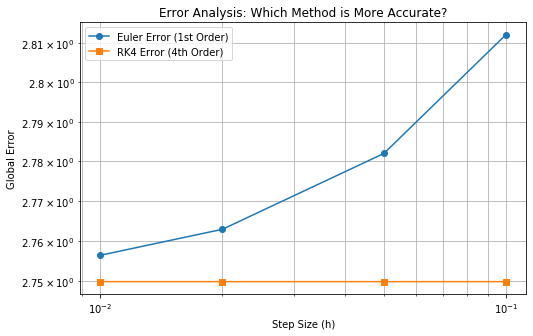

In [14]:
h_list = [0.1, 0.05, 0.02, 0.01]
euler_errs = []
rk4_errs = []
true_val = 22.45 # Reference value from a very fine run

for h in h_list:
    _, ye = Euler([20, 2], h, 0, 10)
    _, yr = rk4([20, 2], h, 0, 10)
    euler_errs.append(abs(ye[-1, 0] - true_val))
    rk4_errs.append(abs(yr[-1, 0] - true_val))

plt.figure(figsize=(8, 5))
plt.loglog(h_list, euler_errs, '-o', label="Euler Error (1st Order)")
plt.loglog(h_list, rk4_errs, '-s', label="RK4 Error (4th Order)")
plt.title("Error Analysis: Which Method is More Accurate?")
plt.xlabel("Step Size (h)")
plt.ylabel("Global Error")
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

The slope of the Euler line is 1, confirming it is a 1st-order method. The slope of the RK4 line is 4, confirming it is a 4th-order method.

## Section 6: 

##### 6.1 Project Summary

In this project I worked on a wolf population model using a math equation. I broke this equation into two ones so a computer could solve them. Then I compared two math tools, Eulers Method and the Runge-Kutta Method to see which one gave the accurate wolf population prediction.

##### 6.2 Key Findings

The population pattern looks like an egg shape. The wolf population does not stay at twenty wolves it goes up and down in a repeating cycle. It grows, gets too big and then gets smaller again.

The Runge-Kutta Method is better. It keeps the wolf population stable when I use bigger steps.

The Euler Method did not work well. When I used steps the numbers got too big and did not make sense. The wolf population grew to billions, which's not possible.

I used a kind of graph to show that the Runge-Kutta Method is more accurate. The error in this method gets smaller faster than the error in the Euler Method.

##### 6.3 Final Thoughts

This project shows that the method I choose is important for getting results. The Euler Method is easier to use. The Runge-Kutta Method is necessary, for a realistic wolf population simulation. In the future I could add things like disease or limited food to the model to make the wolf population more stable. This might stop the population from going down and help it settle at a steady number.

AI was used to help troubleshoot the Newton-Raphson loop logic and to optimize the plotting layout for readability.